In [1]:
!pip install webdriver-manager
!pip install selenium-stealth
import time
from selenium import webdriver
from selenium_stealth import stealth
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from webdriver_manager.chrome import ChromeDriverManager
import re

**Парсим Яндекс Еду.**

-> почему?

Потому что мы хотим продавать сорбет в доставке, а Яндекс Еда один из крупнейших агрегаторов точек, откуда доставляют продукты. Содержит как обычные розничные магазины, так и необыные точки вроде Усачевского рынка, которые тоже перспективны для продажи сорбета

-> зачем?

Хотим определить наиболее удачные потенциальные каналы продаж сорбета в доставке

In [2]:
options = webdriver.ChromeOptions()
options.add_argument('--disable-blink-features=AutomationControlled')
options.add_experimental_option("excludeSwitches", ["enable-automation"])
options.add_experimental_option('useAutomationExtension', False)
options.add_argument("--window-size=1920,1080")

driver = webdriver.Chrome(options=options)

stealth(
    driver,
    languages=["ru-RU", "ru"],
    vendor="Google Inc.",
    platform="Win32",
    webgl_vendor="Intel Inc.",
    renderer="Intel Iris OpenGL Engine",
    fix_hairline=True,
)


There was an error managing chromedriver (error decoding response body); using driver found in the cache


In [3]:
driver.get('https://eda.yandex.ru/search?query=%D1%81%D0%BE%D1%80%D0%B1%D0%B5%D1%82')

In [4]:
button = WebDriverWait(driver, 10).until(EC.element_to_be_clickable((By.CLASS_NAME, "ewc_r1u3cchc")))
button.click()

In [5]:
address_input = WebDriverWait(driver, 10).until(
    EC.presence_of_element_located((By.CSS_SELECTOR, "input[data-testid='address-input']"))
)
address_input.clear()
address_input.send_keys("Москва, Покровский бульвар, 11")
print("Ввели адрес")

time.sleep(1.5)

Ввели адрес


Сейчас из впадающего списка адресов нам нужно выбрать подходящий. Судя по странице, нам подходит первый

In [6]:
time.sleep(1.5)
first_option = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.CSS_SELECTOR, "#react-autowhatever-1--item-0"))
)
first_option.click()

Теперь нажмем на кнопку "ОК" чтобы сохранить адрес и выдача по запросу "сорбет" была корректной

In [7]:
ok_button = WebDriverWait(driver, 10).until(
    EC.element_to_be_clickable((By.CLASS_NAME, "ewc_o16sqpc5"))
)
ok_button.click()

Теперь кликнем на кнопку "магазины" - нас не интересуют рестораны


Для каждого магазина мы хотим вытащить:
* среднюю цену за 100 грамм
* рейтинг магазина для определения потенциальных точек продаж
* среднее число ккал за 100 грамм 

In [8]:
#как предыдущие кнопки эта не кликнулась, на сайте ее что-то перекрывает, принудительно кликнем

shop_span = WebDriverWait(driver, 10).until(
    EC.presence_of_element_located((By.XPATH, "//span[text()='Магазины']"))
)
driver.execute_script("arguments[0].click();", shop_span)

Прокрутим страницу до конца, чтобы собрать все магазины

In [9]:
last_height = driver.execute_script("return document.body.scrollHeight")
print(last_height)

while True:
    driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
    time.sleep(3)

    new_height = driver.execute_script("return document.body.scrollHeight")
    print(new_height)
    if new_height == last_height: #триггерим загрузку еще раз, подвисает 
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight - 100);")
        time.sleep(2)
        driver.execute_script("window.scrollTo(0, document.body.scrollHeight);")
        time.sleep(2)
        final_height = driver.execute_script("return document.body.scrollHeight")
        if final_height == new_height:
            break
    last_height = new_height

9155
17486
21983
21983


In [10]:
shops_category = driver.find_elements(By.CSS_SELECTOR, "div.ewc_r1qgg47t.ewc_r1gvs4ge")
shop_blocks = shops_category[0].find_elements(By.XPATH, "./div")
shop_blocks = shop_blocks[2:]
shop_blocks = shop_blocks[:-1]
print(len(shop_blocks))

49


In [11]:
data_shops = {}

Комментарии по парсингу:
* Сначала рассмотрим просто магазины, которые представлены в доставке. Наша цель: определить потенциально успешные точки сбыта
* У успешной точки сбыта должно быть одновременно много комментариев (популярность) + хороший рейтинг
* Спарсим эти показатели **(r - рейтинг, o - отзывы)**
* Воспользуемся формулой: **score = r * ln(o)**, чтобы сгладить рейтинг между магазинами, у которых много комментариев. Такая формула выдаст больщое значение когда обе переменные большие, маленькое когда обе маленькие / одна слишком маленькая. Такое нам и нужно
* Яндекс лавка внутри HTML имеет элементы, которые динамически изменяются день ото дня -> приходится искать CSS selectors, которые не нужно будет постоянно изменять


In [12]:
for i, shop in enumerate(shop_blocks):
    print(f"Обработка магазина {i+1}/{len(shop_blocks)}")
    name_element = shop.find_element(By.CSS_SELECTOR, "[data-testid='place-header-title']")
    shop_name = name_element.text
    data_shops[shop_name] = {}
    time.sleep(0.5)

    rating_element = shop.find_element(By.CSS_SELECTOR, "[data-testid='place-header-lower-meta'] span")
    shop_rating = rating_element.text
    if shop_rating == 'Мало оценок':
        rating = 0
        comments = 0
    else:
        shop_rating = shop_rating.split(' ')
        rating = shop_rating[0]
        rating = float(rating)
        comments = shop_rating[1]
        comments = comments.strip('()').rstrip('+')
        comments = int(comments)
    data_shops[shop_name]['рейтинг магазина'] = rating 
    data_shops[shop_name]['количество отзывов'] = comments

print(data_shops)



Обработка магазина 1/49
Обработка магазина 2/49
Обработка магазина 3/49
Обработка магазина 4/49
Обработка магазина 5/49
Обработка магазина 6/49
Обработка магазина 7/49
Обработка магазина 8/49
Обработка магазина 9/49
Обработка магазина 10/49
Обработка магазина 11/49
Обработка магазина 12/49
Обработка магазина 13/49
Обработка магазина 14/49
Обработка магазина 15/49
Обработка магазина 16/49
Обработка магазина 17/49
Обработка магазина 18/49
Обработка магазина 19/49
Обработка магазина 20/49
Обработка магазина 21/49
Обработка магазина 22/49
Обработка магазина 23/49
Обработка магазина 24/49
Обработка магазина 25/49
Обработка магазина 26/49
Обработка магазина 27/49
Обработка магазина 28/49
Обработка магазина 29/49
Обработка магазина 30/49
Обработка магазина 31/49
Обработка магазина 32/49
Обработка магазина 33/49
Обработка магазина 34/49
Обработка магазина 35/49
Обработка магазина 36/49
Обработка магазина 37/49
Обработка магазина 38/49
Обработка магазина 39/49
Обработка магазина 40/49
Обработка

In [13]:
import pandas as pd
import numpy as np

In [14]:
df_proizv = pd.DataFrame.from_dict(data_shops, orient='index').reset_index()
df_proizv.rename(columns={'index': 'shop_name', 
                   'рейтинг магазина': 'rating',
                   'количество отзывов': 'reviews'}, inplace=True)
df_proizv

,shop_name,rating,reviews
0,Яндекс Лавка,5.0,200
1,Азбука вкуса,4.9,3100
2,ВкусВилл Гипер,4.9,1900
3,Азбука daily,4.6,257
4,У Палыча,4.8,127
5,ВкусВилл Сгоряча,4.7,300
6,Магнолия,4.3,45
7,КуулКлевер. Продукты МясновЪ,4.5,202
8,Дикси,4.6,172
9,ВкусВилл Экспресс,4.9,624


Удалим из датафрейма те магазины, которые не продают сорбеты-еду, а продают косметику или другие неподходящие товары. Добавляем столбец с посчитанным скором. 

In [15]:
shops_for_delete = {'Селесте', 'Зелёная улица', 'Flawery', 'Точка Любви', 'Кантата', 
                    'ЕАПТЕКА', 'Комус', 'Улыбка радуги', 'М.Косметик', 'М.Косметик Beauty store',
                    'РИВ ГОШ', 'Dolce Milk', 'Аптека.ру', 'Унция', 'Подружка', 'Магнит Мигом', 'Аптека Ригла', 'Самсон Фарма',}
df_proizv.drop(df_proizv[df_proizv['shop_name'].isin(shops_for_delete)].index, inplace=True)
df_proizv['score'] = df_proizv['rating'] * np.log(df_proizv['reviews'])
df_proizv = df_proizv.sort_values('score', ascending=False).reset_index(drop=True)
df_proizv

c:\Users\Lenovo\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,shop_name,rating,reviews,score
0,Азбука вкуса,4.9,3100,39.391871
1,Даниловский рынок,4.6,3700,37.794005
2,ВкусВилл Гипер,4.9,1900,36.993085
3,METRO,4.3,5100,36.709082
4,Глобус,4.6,2600,36.171027
5,Усачёвский рынок,4.5,2600,35.384700
6,Магнит Семейный,4.7,1000,32.466450
7,ВкусВилл Экспресс,4.9,624,31.537137
8,Азбука вкуса Гипермаркет,3.9,1800,29.232614
9,АШАН Гипермаркет,3.6,1900,27.178593


In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

In [17]:
from matplotlib.patches import Patch

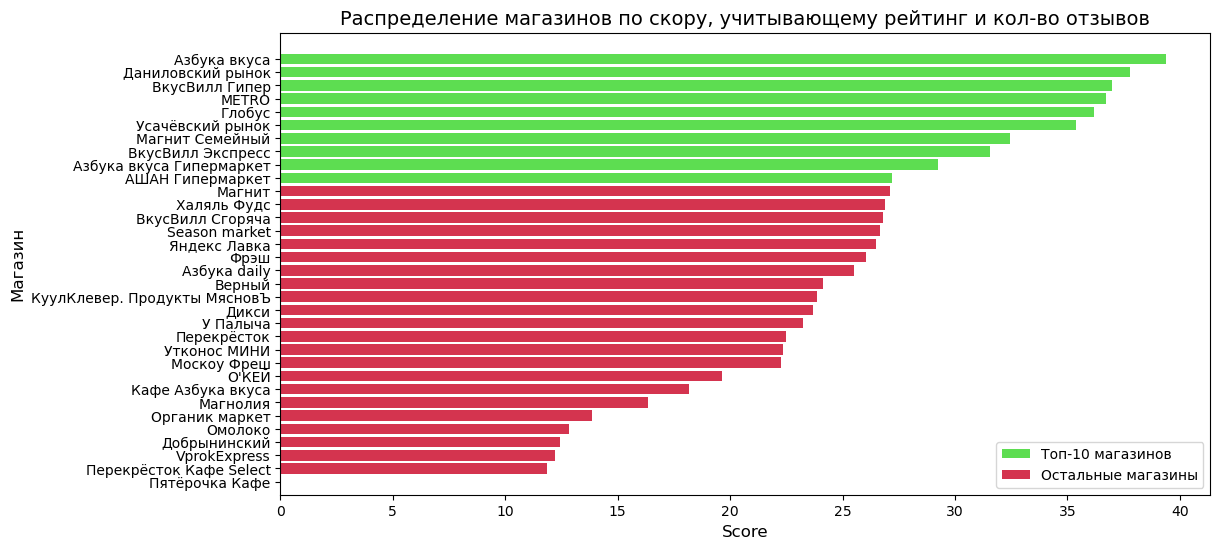

In [18]:
plt.figure(figsize=(12, 6))
colors = ["#5ddd51" if i < 10 else "#d4344f" for i in range(len(df_proizv))]
bars = plt.barh(df_proizv['shop_name'], df_proizv['score'], color=colors)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Магазин', fontsize=12)
plt.title('Распределение магазинов по скору, учитывающему рейтинг и кол-во отзывов', fontsize=14)
plt.gca().invert_yaxis()
legend_elements = [Patch(facecolor="#5ddd51", label='Топ-10 магазинов'), Patch(facecolor="#d4344f", label='Остальные магазины')]
plt.legend(handles=legend_elements, loc='lower right')
plt.show()

**Выводы**:
1. Если мы хотим продавать сорбет через Яндекс Еду, стоит обратить внимание на производителей в зеленой зоне. Они имеют хорошое положение на рынке и наш товар, будучи новым, заслужит дополнительное доверие потребителей из-за того, что такие крупные и well-known сети выбрали его продавать
2. Кроме обычных сетей в зеленой зоне оказались Даниловский и Усачевский рынки. Стоит обратить внимание на эту нишу и рассмотреть продажу на таких рынках тоже.

_________________________________________________________________________________________________________________________________________________

**Гипотеза**: ЗОЖ в последнее время в тренде, поэтому потребители готовы платить больше за пп продукты.

**Проверка**: сравним соотношение цены за гр с калорийностью на гр

Комментарии по парсингу:

* у яндекс еды на сайте чтобы получить все товары из данного магазина нужно прокрутить карусель вправо. При этом элементы, которые были слева могут потеряться
* будем анализировать топ-10 успешных точек продаж с графика выше
* Удаляем из прошлого датасета производителей Даниловский рынок и Усачевский рынок, так как они не пишут данные о каллорийности продукта

In [26]:
shops_for_delete = {'Даниловский рынок', 'Усачёвский рынок'}
df_proizv_2 = df_proizv.drop(df_proizv[df_proizv['shop_name'].isin(shops_for_delete)].index)
df_proizv_2 = df_proizv_2.sort_values('score', ascending=False).reset_index(drop=True)
top_shops = df_proizv_2.head(10)
top_shops

,shop_name,rating,reviews,score
0,Азбука вкуса,4.9,3100,39.391871
1,ВкусВилл Гипер,4.9,1900,36.993085
2,METRO,4.3,5100,36.709082
3,Глобус,4.6,2600,36.171027
4,Магнит Семейный,4.7,1000,32.466450
5,ВкусВилл Экспресс,4.9,624,31.537137
6,Азбука вкуса Гипермаркет,3.9,1800,29.232614
7,АШАН Гипермаркет,3.6,1900,27.178593
8,Магнит,4.4,472,27.090708
9,Халяль Фудс,4.7,304,26.870030


In [27]:
data_sorbets = {}

In [ ]:
# нашли блоки с каждым магазином
shops_category = driver.find_elements(By.CSS_SELECTOR, "div.ewc_r1qgg47t.ewc_r1gvs4ge")
shop_blocks = shops_category[0].find_elements(By.XPATH, "./div")
shop_blocks = shop_blocks[2:] 

data_sorbets = {}

for i, shop in enumerate(shop_blocks):
    print(f"Обработка магазина {i+1}/{len(shop_blocks)}")

    name_element = shop.find_element(By.CSS_SELECTOR, "[data-testid='place-header-title']")
    shop_name = name_element.text
    
    if shop_name in top_shops['shop_name'].values:
        print(f'Обрабатываем магазин {shop_name}')
        processed_products = set()
        product_count = 0

        while True:
            products = shop.find_elements(By.CSS_SELECTOR, '[data-testid="product-card-v2-root"]')
            for j in range(product_count, len(products)):
                try:
                    product = products[j]
                    print(f'Обрабатываем {j + 1} продукт из {len(products)}')
        
                    product_button = product.find_element(By.CSS_SELECTOR, "button")
                    driver.execute_script("arguments[0].click();", product_button)
                    time.sleep(3)

                    product_name = driver.find_element(By.CSS_SELECTOR, '[data-testid="product-full-card-name"]')
                    product_name_text = product_name.text
                    
                    if product_name_text in processed_products:
                        close_button = driver.find_element(By.XPATH, "//button[@aria-label='Закрыть модальное окно']")
                        driver.execute_script("arguments[0].click();", close_button)
                        time.sleep(1)
                        continue
                    
                    processed_products.add(product_name_text)
                    try:
                        type_element = driver.find_element(By.XPATH, 
                            "//h3[@data-testid='product-card-short-block-title' and text()='Вид продукта']/following-sibling::div[@data-testid='product-card-short-block-text']")
                        product_type = type_element.text.lower()
                    except:
                        print("Тип продукта не найден")
                        close_button = driver.find_element(By.XPATH, "//button[@aria-label='Закрыть модальное окно']")
                        driver.execute_script("arguments[0].click();", close_button)
                        time.sleep(1)
                        continue
                    
                    if 'сорбет' in product_type:
                        # Получаем вес
                        try:
                            weight_el = driver.find_element(By.CSS_SELECTOR, '[data-testid="product-full-card-weight"]')
                            weight_text = weight_el.text.strip()
                            weight = float(weight_text[0])
                        except:
                            print(f"Ошибка получения веса")
                            close_button = driver.find_element(By.XPATH, "//button[@aria-label='Закрыть модальное окно']")
                            driver.execute_script("arguments[0].click();", close_button)
                            time.sleep(1)
                            continue

                        # Получаем цену
                        try:
                            price_element = driver.find_element(By.CSS_SELECTOR, "span[class*='hiddenPrice']")
                            price_text = price_element.text
                            price = float(re.search(r'(\d+)', price_text).group(1))
                        except:
                            print(f"Ошибка получения цены")
                            close_button = driver.find_element(By.XPATH, "//button[@aria-label='Закрыть модальное окно']")
                            driver.execute_script("arguments[0].click();", close_button)
                            time.sleep(1)
                            continue

                        callories_g = None
                        try:
                            calories_element = driver.find_element(By.XPATH, 
                                "//div[@data-testid='product-card-nutrients-item-title' and text()='ккал']/preceding-sibling::div[@data-testid='product-card-nutrients-item-value']")
                            calories_text = calories_element.text
                            calories_100 = float(calories_text.replace('&nbsp;', '').strip())
                            callories_g = calories_100 / 100
                            print(f"Калории: {callories_g}")
                        except:
                            print("Калории не найдены для этого товара")
                        
                        price_g = price / weight
                        print(f"Цена за грамм: {price_g}")
                        data_sorbets[product_name_text] = {'price_g': price_g, 'callories_g': callories_g}
                        
                    close_button = driver.find_element(By.XPATH, "//button[@aria-label='Закрыть модальное окно']")
                    driver.execute_script("arguments[0].click();", close_button)
                    time.sleep(1)
                    
                except Exception as e:
                    print(f"Ошибка при обработке товара {j+1}: {e}")
                    try:
                        close_button = driver.find_element(By.XPATH, "//button[@aria-label='Закрыть модальное окно']")
                        driver.execute_script("arguments[0].click();", close_button)
                        time.sleep(1)
                    except:
                        pass
                    continue
                
                product_count += 1

            try:
                next_button = shop.find_element(By.CSS_SELECTOR, "button[aria-label='Следующий слайд']")
                if next_button.is_enabled() and next_button.is_displayed():
                    driver.execute_script("arguments[0].scrollIntoView({block: 'center'});", next_button)
                    time.sleep(1)
                    driver.execute_script("arguments[0].click();", next_button)
                    time.sleep(2)
                else:
                    print("Конец карусели")
                    break
            except:
                print("Конец карусели")
                break

print(data_sorbets)

Обработка магазина 1/50
Обработка магазина 2/50
Обрабатываем магазин Азбука вкуса
Обрабатываем 1 продукт из 15
Калории: 1.03
Цена за грамм: 17.0
Обрабатываем 2 продукт из 15
Калории: 1.03
Цена за грамм: 1.0
Обрабатываем 3 продукт из 15
Калории: 0.96
Цена за грамм: 20.285714285714285
Обрабатываем 4 продукт из 15
Калории: 0.96
Цена за грамм: 1.0
Обрабатываем 5 продукт из 15
Калории: 1.06
Цена за грамм: 1.0
Обрабатываем 6 продукт из 15
Калории: 1.07
Цена за грамм: 58.42857142857143
Обрабатываем 7 продукт из 15
Калории: 1.1
Цена за грамм: 58.42857142857143
Обрабатываем 8 продукт из 15
Обрабатываем 9 продукт из 15
Обрабатываем 10 продукт из 15
Калории: 1.15
Цена за грамм: 287.5
Обрабатываем 11 продукт из 15
Обрабатываем 12 продукт из 15
Калории: 1.06
Цена за грамм: 269.5
Обрабатываем 13 продукт из 15
Калории: 1.14
Цена за грамм: 0.3333333333333333
Обрабатываем 14 продукт из 15
Калории: 1.13
Цена за грамм: 237.33333333333334
Обрабатываем 15 продукт из 15
Калории: 1.7
Цена за грамм: 179.66666

Ограничения такого метода обработки:
* ловит только продукты у которых указан тип сорбет. Если тип напрямую не указан, а только в названии, то не ловит. Из названия сложно отделять что с ароматом сорбета, называется сорбет, а на самом деле не сорбет и тд
* там, где каллории не указаны в специальном месте, а только в описании, тоже не собирает. 

In [34]:
df_sorbets = pd.DataFrame.from_dict(data_sorbets, orient='index').reset_index()
df_sorbets.rename(columns={'index': 'product_name', 
                           'price_g': 'price_per_gram',
                           'callories_g': 'calories_per_gram'}, inplace=True)
df_sorbets

,product_name,price_per_gram,calories_per_gram
0,Сорбет Fine Life малиновый 75 г,17.000000,1.030
1,Сорбет Metro Chef лайм замороженный,1.000000,1.030
2,Сорбет Fine Life манго-маракуйя без сахара 75 г,20.285714,0.960
3,"Сорбет Metro Chef манго замороженный, 1.5кг",1.000000,0.960
4,Сорбет Metro Chef малина замороженный,1.000000,1.060
5,Мороженое сорбет Minimelts Вишня 72 г,58.428571,1.070
6,Мороженое сорбет Minimelts Манго 72 г,58.428571,1.100
7,Сорбет Amore лимон из Палермо 300 мл,287.500000,1.150
8,Сорбет Amore нежная малина 300 мл,269.500000,1.060
9,Сорбет Лимон Tonitto 310 г,0.333333,1.140


Попытаемся понять, если связь между ценой за грамм и каллорийностью за грамм, построив графики

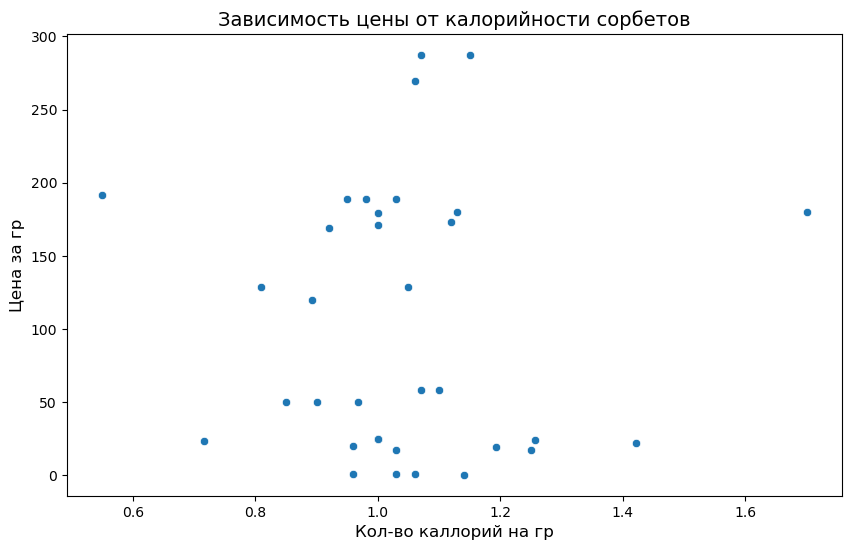

In [41]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_sorbets, x='calories_per_gram', y='price_per_gram')
plt.xlabel('Кол-во каллорий на гр', fontsize=12)
plt.ylabel('Цена за гр', fontsize=12)
plt.title('Зависимость цены от калорийности сорбетов', fontsize=14)
plt.show()

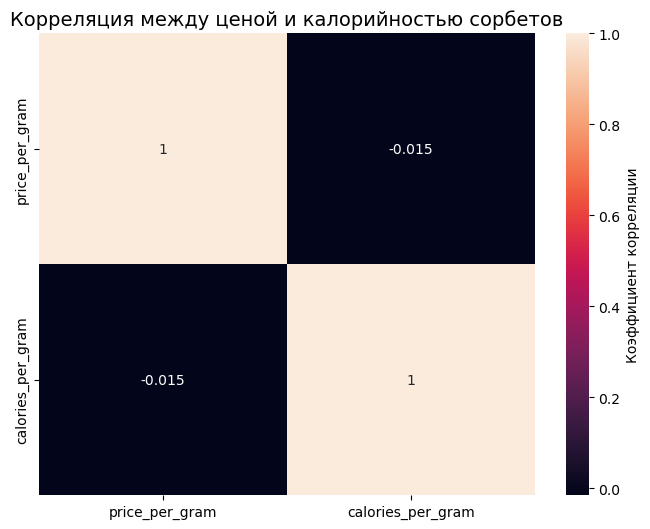

Коэффициент корреляции: -0.015122339899595348


In [40]:
corr_matrix = df_sorbets[['price_per_gram', 'calories_per_gram']].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cbar_kws={"label": "Коэффициент корреляции"})
plt.title('Корреляция между ценой и калорийностью сорбетов', fontsize=14)
plt.show()

print(f"Коэффициент корреляции: {corr_matrix.iloc[0, 1]}")

**Выводы**

Мы видим, что коеффициент корреляции маленький -> прямой корреляции между количеством каллорий за грамм и ценой за грамм нет. Если мы хотим сделать доп профит на ЗОЖе, то нужно опираться именно на позиционирование бренда, а не прямое количество каллорий